In [1]:
from upsetplot import plot

ModuleNotFoundError: No module named 'upsetplot'

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

/cluster/project/treutlein/jjans/software/miniforge3/envs/scenicplus/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
import pandas as pd
import numpy as np
import os, glob, math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE       = "/cluster/project/treutlein/USERS/jjans/analysis/adult_intestine/peaks"
CONS_DIR   = f"{BASE}/cross_species_consensus_v3"
DESEQ_DIR  = f"{CONS_DIR}/13_deseq2_R_pseudobulk"
ANNO_PATH  = f"{CONS_DIR}/07_master_annotation/master_annotation_corrected.tsv"
FRAG_DIR   = f"{CONS_DIR}/12_fragment_matrices"
ROBUST_DIR = f"{DESEQ_DIR}/differential_results/ultra_robust_branches"
BRANCH_DIR = f"{DESEQ_DIR}/differential_results/evolutionary_branches"

SPECIES    = ["Human", "Bonobo", "Chimpanzee", "Gorilla", "Macaque", "Marmoset"]

# ── Load corrected annotation ─────────────────────────────────────────────────
print("Loading annotation...")
anno = pd.read_csv(ANNO_PATH, sep="\t", low_memory=False).set_index("peak_id")
orth_cols = {sp: f"{sp}_orth" for sp in SPECIES}
det_cols  = {sp: f"{sp}_det"  for sp in SPECIES}
print(f"  {anno.shape[0]:,} peaks × {anno.shape[1]} columns")

Loading annotation...
  1,142,003 peaks × 59 columns


In [4]:
anno.columns

Index(['peak_type', 'species_detected', 'n_species_det', 'n_species_orth',
       'Human_det', 'Bonobo_det', 'Chimpanzee_det', 'Gorilla_det',
       'Macaque_det', 'Marmoset_det', 'Human_orth', 'Bonobo_orth',
       'Chimpanzee_orth', 'Gorilla_orth', 'Macaque_orth', 'Marmoset_orth',
       'Human_chr', 'Human_start', 'Human_end', 'Bonobo_chr', 'Bonobo_start',
       'Bonobo_end', 'Chimpanzee_chr', 'Chimpanzee_start', 'Chimpanzee_end',
       'Gorilla_chr', 'Gorilla_start', 'Gorilla_end', 'Macaque_chr',
       'Macaque_start', 'Macaque_end', 'Marmoset_chr', 'Marmoset_start',
       'Marmoset_end', 'Human_gene', 'Human_gene_dist', 'Bonobo_gene',
       'Bonobo_gene_dist', 'Chimpanzee_gene', 'Chimpanzee_gene_dist',
       'Gorilla_gene', 'Gorilla_gene_dist', 'Macaque_gene',
       'Macaque_gene_dist', 'Marmoset_gene', 'Marmoset_gene_dist',
       'Human_region', 'Bonobo_region', 'Chimpanzee_region', 'Gorilla_region',
       'Macaque_region', 'Marmoset_region', 'Human_unidirectional_liftov

In [6]:
anno.loc['unified_000002']

peak_type                                           unified
species_detected                                      Human
n_species_det                                             1
n_species_orth                                            5
Human_det                                                 1
Bonobo_det                                                0
Chimpanzee_det                                            0
Gorilla_det                                               0
Macaque_det                                               0
Marmoset_det                                              0
Human_orth                                                1
Bonobo_orth                                               0
Chimpanzee_orth                                           1
Gorilla_orth                                              1
Macaque_orth                                              1
Marmoset_orth                                             1
Human_chr                               

In [9]:
det_cols

['Human_det',
 'Bonobo_det',
 'Chimpanzee_det',
 'Gorilla_det',
 'Macaque_det',
 'Marmoset_det']

In [7]:
df_det

,Human_det,Bonobo_det,Chimpanzee_det,Gorilla_det,Macaque_det,Marmoset_det
peak_id,,,,,,
human_peak_000001,True,False,False,False,False,False
unified_000001,True,False,False,False,False,False
human_peak_000002,True,False,False,False,False,False
human_peak_000003,True,False,False,False,False,False
unified_000002,True,False,False,False,False,False
...,...,...,...,...,...,...
marmoset_peak_053001,False,False,False,False,False,True
marmoset_peak_053002,False,False,False,False,False,True
marmoset_peak_053003,False,False,False,False,False,True


In [10]:
import matplotlib.pyplot as plt
from upsetplot import plot
import pandas as pd

# 1. Define a strict cleaning function
def clean_to_bool(val):
    # Catch actual NaN/Null values
    if pd.isna(val):
        return False
    
    # Convert everything to lowercase strings and strip spaces
    val_str = str(val).strip().lower()
    
    # Map known "truthy" string variants to True
    if val_str in ['1', '1.0', 'true', 'yes', 'y', 't']:
        return True
    
    # Everything else ("0", "nan", "false", "") defaults to False
    return False

# 2. Subset and clean the Detection Data
df_det = anno[det_cols].copy()
for col in det_cols:
    df_det[col] = df_det[col].map(clean_to_bool)

det_counts = df_det.groupby(det_cols).size()

# 3. Subset and clean the Orthologous Data
df_orth = anno[orth_cols].copy()
for col in orth_cols:
    df_orth[col] = df_orth[col].map(clean_to_bool)

orth_counts = df_orth.groupby(orth_cols).size()


In [11]:
orth_counts

Human_orth  Bonobo_orth  Chimpanzee_orth  Gorilla_orth  Macaque_orth  Marmoset_orth
False       False        False            False         False         True              53005
                                                        True          False             17863
                                          True          False         False             13861
                         True             False         False         False              8352
            True         False            False         False         False              9586
True        False        False            False         False         False              3202
                                                                      True               1997
                                                        True          False               565
                                                                      True               1469
                                          True          False         

In [12]:
from upsetplot import generate_counts

In [13]:
example = generate_counts()


In [14]:
from upsetplot import plot

/cluster/project/treutlein/jjans/software/miniforge3/envs/scenicplus/lib/python3.11/site-packages/upsetplot/plotting.py:795: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  styles["linewidth"].fillna(1, inplace=True)
/cluster/project/treutlein/jjans/software/miniforge3/envs/scenicplus/lib/python3.11/site-packages/upsetplot/plotting.py:

ValueError: Invalid RGBA argument: nan

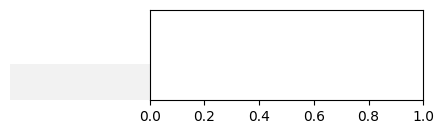

In [15]:
plot(example)  
